# max_declines effect

Does capping the declines a driver may make per request (max_declines = 3)
recover service quality, and at what cost to driver satisfaction? Each metric
is a delta (max3 - unlimited) matched per (d, R, behaviour,
initial_conditions). Plots: delta service rate vs R, decline count reduction,
driver welfare cost (satisfaction, income Gini), and a service vs satisfaction
scatter with both variants next to the Exp 1 baseline.

The `*_max3` runs are produced separately. If they are not cached yet the
notebook prints what is missing and skips the plots.

Summary data only.


In [ ]:
from pathlib import Path

GEOMETRY = 'balanced'          # 'balanced' or 'imbalanced'
BASELINE = 'exp1'              # nearest, for the service recovery comparison
PAIR_EXPS = ['exp2', 'exp3', 'exp5', 'exp6']   # experiments with a max3 variant

CACHE_DIR = Path('.') / 'cache'
FORCE_RECOMPUTE = False

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('.').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from exp_utils import load_experiment_set, match_run_pairs, fmt_display, exp_label, apply_pub_style, legend_outside

apply_pub_style()

## 1. Load unlimited and max3 variants

`load_experiment_set(include_max3=True)` returns both the unlimited and the
max_declines=3 runs. They share the same `experiment` id, so the variant is
read from the `group` name suffix.


In [ ]:
df = load_experiment_set(GEOMETRY, cache_dir=CACHE_DIR, include_max3=True,
                         force=FORCE_RECOMPUTE)
if df.empty:
    raise RuntimeError(f'No data for geometry={GEOMETRY!r}. Run cache_all.py first.')

df['variant'] = np.where(df['group'].str.endswith('_max3'), 'max3', 'unlimited')

EXP_ALGO = df.drop_duplicates('experiment').set_index('experiment')['algorithm'].to_dict()
KEYS = ['d', 'R', 'behaviour', 'initial_conditions']
R_vals = sorted(df['R'].dropna().unique())

present_pairs = []
for e in PAIR_EXPS:
    has_un = not df[(df['experiment'] == e) & (df['variant'] == 'unlimited')].empty
    has_m3 = not df[(df['experiment'] == e) & (df['variant'] == 'max3')].empty
    if has_un and has_m3:
        present_pairs.append(e)
    else:
        miss = 'max3' if has_un else ('unlimited' if has_m3 else 'both')
        print(f'  {e}: missing {miss} variant')

HAVE_MAX3 = len(present_pairs) > 0
PLABEL = {e: exp_label(e, EXP_ALGO.get(e, '?')) for e in PAIR_EXPS}
_cmap = plt.get_cmap('tab10')
PCOLOR = {e: _cmap(i % 10) for i, e in enumerate(PAIR_EXPS)}

if HAVE_MAX3:
    print('Pairs available:', [PLABEL[e] for e in present_pairs])
else:
    print('No max3 runs cached yet - sections below will skip until they exist.')

In [4]:
# Metrics for the max3 - unlimited delta (positive = max3 is higher).
DELTA_METRICS = [
    ('service_rate',            'Service rate',        '{:+.3f}'),
    ('avg_total_declines',      'Declines/driver',     '{:+.2f}'),
    ('final_satisfaction_mean', 'Satisfaction',        '{:+.2f}'),
    ('income_gini',             'Income Gini',         '{:+.3f}'),
    ('final_safety_mean',       'Driver safety',       '{:+.2f}'),
    ('wait_to_pickup_mean',     'Wait to pickup (TU)', '{:+.0f}'),
]
DELTA_METRICS = [(c, l, f) for c, l, f in DELTA_METRICS if c in df.columns]
DELTA_COLS = [c for c, _, _ in DELTA_METRICS]


def max3_deltas(e):
    un = df[(df['experiment'] == e) & (df['variant'] == 'unlimited')]
    m3 = df[(df['experiment'] == e) & (df['variant'] == 'max3')]
    m = match_run_pairs(un, m3, keys=KEYS)
    out = m[KEYS].copy()
    for col in DELTA_COLS:
        a, b = f'{col}_exp1', f'{col}_exp2'      # _exp1 = unlimited, _exp2 = max3
        if a in m.columns and b in m.columns:
            out[col] = m[b] - m[a]
    out['experiment'] = e
    return out


deltas = {e: max3_deltas(e) for e in present_pairs} if HAVE_MAX3 else {}
if HAVE_MAX3:
    print('matched pairs:', {e: len(v) for e, v in deltas.items()})

matched pairs: {'exp2': 60, 'exp3': 60, 'exp5': 60, 'exp6': 60}


## 2. Service rate recovery

Delta service rate (max3 - unlimited) vs R. Positive = capping declines brings
service back up. Read alongside Section 5 to see whether it recovers service toward
the nearest baseline.

In [ ]:
if not HAVE_MAX3:
    print('skipped: no max3 data')
else:
    fig, ax = plt.subplots(figsize=(8, 5))
    for e in present_pairs:
        g = deltas[e].groupby('R')['service_rate'].agg(['mean', 'std']).reindex(R_vals)
        ax.errorbar(R_vals, g['mean'].values, yerr=g['std'].values, fmt='o-',
                    color=PCOLOR[e], label=PLABEL[e], capsize=3, linewidth=1.6)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Demand ratio R')
    ax.set_ylabel('delta service rate (max3 - unlimited)')
    ax.set_title(f'Service rate recovery from max_declines=3 - {GEOMETRY}')
    ax.set_xticks(R_vals)
    fig.tight_layout()
    legend_outside(fig, ax=ax)
    plt.show()

## 3. Decline count reduction

How many fewer declines per driver happen under max_declines=3.

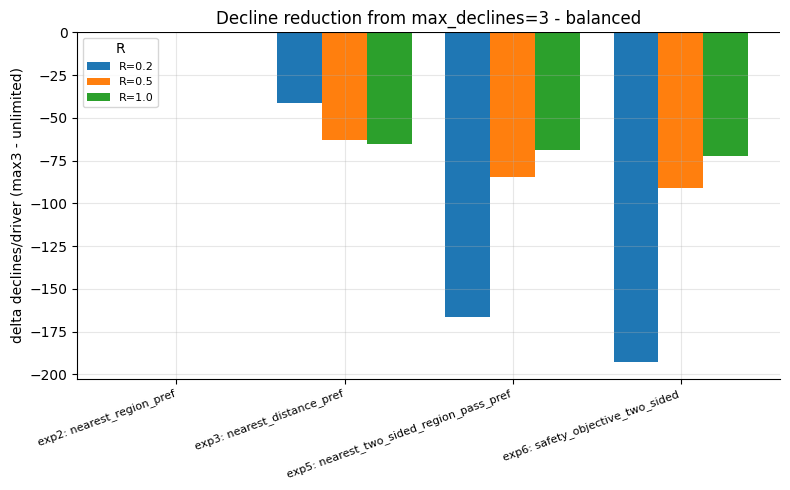

In [6]:
if not HAVE_MAX3 or 'avg_total_declines' not in df.columns:
    print('skipped: no max3 data or no decline column')
else:
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(present_pairs))
    w = 0.8 / max(len(R_vals), 1)
    for i, r in enumerate(R_vals):
        vals = [deltas[e][deltas[e]['R'] == r]['avg_total_declines'].mean()
                for e in present_pairs]
        ax.bar(x + i * w, vals, w, label=f'R={r}')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x + w * (len(R_vals) - 1) / 2)
    ax.set_xticklabels([PLABEL[e] for e in present_pairs], rotation=20,
                       ha='right', fontsize=12)
    ax.set_ylabel('delta declines/driver (max3 - unlimited)')
    ax.set_title(f'Decline reduction from max_declines=3 - {GEOMETRY}')
    ax.legend(title='R', fontsize=12)
    plt.tight_layout()
    plt.show()

## 4. Driver welfare cost

Delta satisfaction and delta income Gini (max3 - unlimited). Quantifies what
forced acceptance costs the drivers.


In [ ]:
if not HAVE_MAX3:
    print('skipped: no max3 data')
else:
    cost_metrics = [m for m in [('final_satisfaction_mean', 'delta satisfaction'),
                                ('income_gini', 'delta income Gini'),
                                ('final_safety_mean', 'delta driver safety')]
                    if m[0] in DELTA_COLS]
    fig, axes = plt.subplots(1, len(cost_metrics), figsize=(3.4 * len(cost_metrics), 3.5))
    axes = np.atleast_1d(axes)
    for ax, (col, label) in zip(axes, cost_metrics):
        for e in present_pairs:
            g = deltas[e].groupby('R')[col].mean().reindex(R_vals)
            ax.plot(R_vals, g.values, 'o-', color=PCOLOR[e], label=PLABEL[e],
                    linewidth=1.6, markersize=4)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xlabel('Demand ratio R')
        ax.set_ylabel(label)
        ax.set_title(label)
        ax.set_xticks(R_vals)
    fig.suptitle(f'Driver welfare cost of max_declines=3 - {GEOMETRY}', y=1.03)
    fig.tight_layout()
    legend_outside(fig, ax=axes[0])
    plt.show()

## 5. Does max_declines recover service toward the baseline?

Service rate vs satisfaction for the unlimited variant, the max3 variant, and the
Exp 1 nearest baseline, averaged per R. If max3 moves each algorithm toward the
baseline's service rate without collapsing satisfaction, the cap is worthwhile.

In [ ]:
if not HAVE_MAX3:
    print('skipped: no max3 data')
else:
    base = df[(df['experiment'] == BASELINE) & (df['variant'] == 'unlimited')]
    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    label_pts = []   # (service_rate, satisfaction, R) for every plotted marker
    for e in present_pairs:
        for variant, marker in [('unlimited', 'o'), ('max3', 's')]:
            s = df[(df['experiment'] == e) & (df['variant'] == variant)]
            g = s.groupby('R')[['service_rate', 'final_satisfaction_mean']].mean()
            ax.scatter(g['service_rate'], g['final_satisfaction_mean'],
                       color=PCOLOR[e], marker=marker, s=80,
                       edgecolor='black', linewidth=0.4,
                       label=f'{e} {variant}')
            for r in g.index:
                label_pts.append((g.loc[r, 'service_rate'],
                                  g.loc[r, 'final_satisfaction_mean'], r))
    if not base.empty:
        gb = base.groupby('R')[['service_rate', 'final_satisfaction_mean']].mean()
        ax.scatter(gb['service_rate'], gb['final_satisfaction_mean'],
                   color='black', marker='*', s=200, label=f'{BASELINE} baseline')
        for r in gb.index:
            label_pts.append((gb.loc[r, 'service_rate'],
                              gb.loc[r, 'final_satisfaction_mean'], r))

    # Color+marker+legend already identify experiment and variant, so the only
    # information an annotation adds is R. Points cluster tightly by R, which made
    # identical 'R=' strings stack illegibly. Group markers within a tolerance and
    # draw one offset label per visual cluster instead.
    sr_arr = np.array([p[0] for p in label_pts])
    sat_arr = np.array([p[1] for p in label_pts])
    xr = (sr_arr.max() - sr_arr.min()) or 1.0
    yr = (sat_arr.max() - sat_arr.min()) or 1.0
    tol_x, tol_y = 0.04 * xr, 0.06 * yr
    clusters = []
    for sr, sat, r in label_pts:
        for c in clusters:
            if abs(sr - c['cx']) <= tol_x and abs(sat - c['cy']) <= tol_y:
                c['xs'].append(sr); c['ys'].append(sat); c['Rs'].add(r)
                c['cx'], c['cy'] = np.mean(c['xs']), np.mean(c['ys'])
                break
        else:
            clusters.append({'xs': [sr], 'ys': [sat], 'Rs': {r}, 'cx': sr, 'cy': sat})
    for c in clusters:
        txt = 'R=' + ', '.join(f'{r:g}' for r in sorted(c['Rs']))
        ax.annotate(txt, (max(c['xs']), max(c['ys'])),
                    textcoords='offset points', xytext=(5, 5),
                    fontsize=11, alpha=0.85)

    ax.set_xlabel('Service rate')
    ax.set_ylabel('Mean satisfaction')
    ax.set_title(f'max_declines service recovery vs baseline - {GEOMETRY}\n'
                 f'circle = unlimited, square = max3, star = {BASELINE}')
    ax.legend(fontsize=12, ncol=2)
    plt.tight_layout()
    plt.show()

## Significance

Sweep paired Wilcoxon of max3 vs unlimited within each experiment
(`group_col='group'`, positive delta = max3 higher), Holm corrected within each
metric (see `guides/STATISTICAL_ANALYSIS_PLAN.md`). The max3 variants were not
replicated, so the focus point columns stay NaN and the sweep test is the one
that applies.


In [9]:
from exp_utils import significance_summary, FOCUS_SETUP

# max3 vs unlimited, paired by (d,R,behaviour,ic) within each experiment.
# group_col='group' names the variant groups; positive delta = max3 higher.
# The max3 variants were NOT replicated, so the focus columns are NaN here - the
# sweep paired Wilcoxon is the test that applies.
df_reps = load_experiment_set(GEOMETRY, cache_dir=CACHE_DIR, include_max3=True,
                              include_reps=True, force=FORCE_RECOMPUTE)

COMPARISONS = [(f'{e}_{GEOMETRY}_max3', f'{e}_{GEOMETRY}')
               for e in present_pairs]
sig = significance_summary(df, df_reps, COMPARISONS, DELTA_COLS,
                           setup=FOCUS_SETUP, group_col='group')
SIG_SHOW = ['comparison', 'metric', 'sweep_n', 'sweep_p_adj', 'sweep_cliff', 'sweep_mag',
            'sweep_signs', 'foc_diff', 'foc_ci_lo', 'foc_ci_hi', 'foc_welch_p',
            'foc_mw_p', 'foc_p_adj', 'foc_cohens_d']
SIG_FMT = {'sweep_p_adj': '{:.2g}', 'sweep_cliff': '{:+.2f}', 'foc_diff': '{:+.3f}',
           'foc_ci_lo': '{:+.3f}', 'foc_ci_hi': '{:+.3f}', 'foc_welch_p': '{:.2g}',
           'foc_mw_p': '{:.2g}', 'foc_p_adj': '{:.2g}', 'foc_cohens_d': '{:+.2f}'}
SIG_SHOW = [c for c in SIG_SHOW if c in sig.columns]
display(fmt_display(sig[SIG_SHOW], fmt=SIG_FMT))

[cache HIT]  exp1_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp2_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp2_balanced_max3_summary.pkl  ->  loading summary
[cache HIT]  exp3_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp3_balanced_max3_summary.pkl  ->  loading summary
[cache HIT]  exp4_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp5_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp5_balanced_max3_summary.pkl  ->  loading summary
[cache HIT]  exp6_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp6_balanced_max3_summary.pkl  ->  loading summary
[cache HIT]  exp7_balanced_summary.pkl  ->  loading summary


,comparison,metric,sweep_n,sweep_p_adj,sweep_cliff,sweep_mag,sweep_signs,foc_diff,foc_ci_lo,foc_ci_hi,foc_welch_p,foc_mw_p,foc_p_adj,foc_cohens_d
0,exp2_balanced_max3 vs exp2_balanced,service_rate,60,0.0078,-0.07,negligible,40/60 a<b,-,-,-,-,-,-,-
1,exp2_balanced_max3 vs exp2_balanced,avg_total_declines,60,9.1e-08,-0.13,negligible,49/60 a<b,-,-,-,-,-,-,-
2,exp2_balanced_max3 vs exp2_balanced,final_satisfaction_mean,60,0.07,+0.04,negligible,36/60 a>b,-,-,-,-,-,-,-
3,exp2_balanced_max3 vs exp2_balanced,income_gini,60,0.11,-0.05,negligible,37/60 a<b,-,-,-,-,-,-,-
4,exp2_balanced_max3 vs exp2_balanced,final_safety_mean,60,1,+0.00,negligible,31/60 a<b,-,-,-,-,-,-,-
5,exp2_balanced_max3 vs exp2_balanced,wait_to_pickup_mean,60,0.13,+0.01,negligible,37/60 a>b,-,-,-,-,-,-,-
6,exp3_balanced_max3 vs exp3_balanced,service_rate,60,0.0064,-0.11,negligible,45/60 a<b,-,-,-,-,-,-,-
7,exp3_balanced_max3 vs exp3_balanced,avg_total_declines,60,6.5e-11,-0.56,large,60/60 a<b,-,-,-,-,-,-,-
8,exp3_balanced_max3 vs exp3_balanced,final_satisfaction_mean,60,6.5e-11,-0.26,small,60/60 a<b,-,-,-,-,-,-,-
9,exp3_balanced_max3 vs exp3_balanced,income_gini,60,7.8e-07,-0.27,small,50/60 a<b,-,-,-,-,-,-,-
